#### Depth Anything V2 — Hugging Face 직접 사용 (`raw`)

`transformers`의 `AutoImageProcessor` + `AutoModelForDepthEstimation`으로 단안 깊이를 추정합니다.

**입력:** 로컬 **RGB 이미지** 파일 경로(`img_path` 등), Hugging Face **`MODEL_ID`**(예: `depth-anything/Depth-Anything-V2-Large-hf`). 선택 셀의 3D 시각화에서는 같은 깊이 맵과 원본 색, (옵션) 카메라 내·외부 파라미터·`max_depth` 스케일.

**출력:** 입력과 같은 그리드 크기의 **`float32` 깊이 맵** (H×W). 값은 **[0,1]** 로 정규화되며 **0=가까움, 1=멀음**인 **상대 깊이**(미터 단위 아님). `plot_depth` / `plot_comparison` 등 **matplotlib** 그림, (선택) **포인트클라우드**.

**의존성:** `torch`, `transformers`, `pillow`, `numpy`, `matplotlib`  
3D 시각화(선택): `open3d`

```bash
pip install torch transformers pillow numpy matplotlib accelerate
```

**디바이스:** 환경 변수 `DEPTH_ANYTHING_DEVICE`가 `cuda` / `mps` / `cpu` 이면 우선 사용, 없으면 **CUDA → MPS → CPU**.

출력 깊이 맵은 **0=near, 1=far** 로 [0,1] 정규화된 상대 깊이입니다 (메트릭 아님).

In [1]:
import os

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

from transformers import AutoImageProcessor, AutoModelForDepthEstimation

In [2]:
def pick_torch_device(verbose: bool = True) -> torch.device:
    forced = os.environ.get("DEPTH_ANYTHING_DEVICE", "").strip().lower()
    if forced in ("cuda", "mps", "cpu"):
        if forced == "cuda" and not torch.cuda.is_available():
            raise RuntimeError("DEPTH_ANYTHING_DEVICE=cuda 인데 CUDA를 쓸 수 없습니다.")
        if forced == "mps":
            if not (hasattr(torch.backends, "mps") and torch.backends.mps.is_available()):
                raise RuntimeError("DEPTH_ANYTHING_DEVICE=mps 인데 MPS를 쓸 수 없습니다.")
        if verbose:
            print(f"[device] DEPTH_ANYTHING_DEVICE=[{forced}]")
        return torch.device(forced)
    if torch.cuda.is_available():
        if verbose:
            print("[device] CUDA")
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        if verbose:
            print("[device] MPS")
        return torch.device("mps")
    if verbose:
        print("[device] CPU")
    return torch.device("cpu")


def rgb_img_np(img_np):
    a = np.asarray(img_np)
    if a.ndim == 2:
        a = np.stack([a, a, a], axis=-1)
    return a


def to_pil_rgb(x):
    if hasattr(x, "convert"):
        return x.convert("RGB")
    arr = np.asarray(x)
    if arr.ndim == 2:
        arr = np.stack([arr, arr, arr], axis=-1)
    if arr.dtype != np.uint8:
        arr = arr.astype(np.float32)
        if arr.max() <= 1.0 + 1e-6:
            arr = arr * 255.0
        arr = np.clip(arr, 0, 255).astype(np.uint8)
    return Image.fromarray(arr).convert("RGB")


def _fig_h(fig_w, h, w):
    return float(fig_w) * float(h) / max(1.0, float(w))


def _viz_title(ax, title, title_fs, title_overlay):
    if title is None:
        return
    if title_overlay:
        ax.text(
            0.01,
            0.99,
            str(title),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=int(title_fs),
            color="white",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.35, edgecolor="none"),
            clip_on=False,
        )


def _make_fig_ax(fig_w, fig_h, dpi, pad_px, w, h):
    fig = plt.figure(figsize=(float(fig_w), float(fig_h)), dpi=int(dpi), constrained_layout=False)
    fig.set_constrained_layout(False)
    p = int(max(0, pad_px))
    if p > 0:
        fw_px = float(fig.get_figwidth() * fig.dpi)
        fh_px = float(fig.get_figheight() * fig.dpi)
        l = float(p) / fw_px
        b = float(p) / fh_px
        r = 1.0 - float(p) / fw_px
        t = 1.0 - float(p) / fh_px
        ax = fig.add_axes([l, b, max(0.0, r - l), max(0.0, t - b)])
    else:
        ax = fig.add_axes([0.0, 0.0, 1.0, 1.0])
    ax.set_xlim(-0.5, float(w) - 0.5)
    ax.set_ylim(float(h) - 0.5, -0.5)
    ax.set_autoscale_on(False)
    ax.set_axis_off()
    return fig, ax


@torch.inference_mode()
def predict_depth_map(model, processor, device, img_pil: Image.Image):
    """(H,W) float32, 0=near, 1=far."""
    img_pil = to_pil_rgb(img_pil)
    w, h = img_pil.size
    inputs = processor(images=img_pil, return_tensors="pt")
    for k in inputs:
        t = inputs[k]
        if hasattr(t, "to"):
            inputs[k] = t.to(device)
    outputs = model(**inputs)
    pred = outputs.predicted_depth
    pred = F.interpolate(pred.unsqueeze(1), size=(h, w), mode="bilinear", align_corners=False)
    depth = pred[0, 0].float().cpu().numpy().astype(np.float32)
    d_min = float(np.min(depth))
    d_max = float(np.max(depth))
    if d_max - d_min > 1e-8:
        depth = (depth - d_min) / (d_max - d_min)
    else:
        depth = np.zeros_like(depth)
    depth = 1.0 - depth
    return depth


def plot_depth(img_np, depth_map, fig_w=5, dpi=120, pad_px=0, cmap="inferno", show_cb=True, cbar_fs=7,
               title_img="Input", title_depth="Depth", title_fs=9, title_overlay=True):
    img = rgb_img_np(img_np)
    H, W = img.shape[:2]
    fig_h = _fig_h(fig_w, H, W)
    fig, ax = _make_fig_ax(fig_w, fig_h, dpi, pad_px, W, H)
    ax.imshow(img)
    _viz_title(ax, title_img, title_fs, title_overlay)
    plt.show()
    plt.close(fig)

    fig, ax = _make_fig_ax(fig_w, fig_h, dpi, pad_px, W, H)
    im = ax.imshow(depth_map, cmap=str(cmap), vmin=0, vmax=1)
    _viz_title(ax, title_depth, title_fs, title_overlay)
    if show_cb:
        cbar_w, cbar_h = 0.028, 0.40
        cbar_l, cbar_b = 1.0 - cbar_w - 0.015, 0.06
        cax = fig.add_axes([cbar_l, cbar_b, cbar_w, cbar_h])
        ticks = [0.0, 0.25, 0.5, 0.75, 1.0]
        cbar = fig.colorbar(im, cax=cax, ticks=ticks, format="%.2f")
        cbar.ax.tick_params(labelsize=int(cbar_fs))
        cbar.set_label("near ← → far", fontsize=int(cbar_fs))
        cax.set_facecolor((0, 0, 0, 0))
    plt.show()
    plt.close(fig)


def plot_comparison(img_np, depth_map, fig_w=10, dpi=120, cmap="inferno", title_img="Input",
                    title_depth="Depth", title_fs=10):
    img = rgb_img_np(img_np)
    H, W = img.shape[:2]
    fig_h = float(fig_w) * 0.5 * float(H) / max(1.0, float(W))
    fig, axes = plt.subplots(1, 2, figsize=(float(fig_w), fig_h), dpi=int(dpi))
    axes[0].imshow(img)
    axes[0].set_title(str(title_img), fontsize=int(title_fs))
    axes[0].axis("off")
    im = axes[1].imshow(depth_map, cmap=str(cmap), vmin=0, vmax=1)
    axes[1].set_title(str(title_depth), fontsize=int(title_fs))
    axes[1].axis("off")
    cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label("near ← → far", fontsize=8)
    cbar.ax.tick_params(labelsize=7)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def depth_to_pointcloud(depth_map, img_np=None, fx=None, fy=None, cx=None, cy=None, max_depth=10.0):
    H, W = depth_map.shape
    if fx is None:
        fx = float(W)
    if fy is None:
        fy = float(W)
    if cx is None:
        cx = float(W) / 2.0
    if cy is None:
        cy = float(H) / 2.0
    u, v = np.meshgrid(np.arange(W), np.arange(H))
    u = u.astype(np.float32)
    v = v.astype(np.float32)
    z = depth_map.astype(np.float32) * float(max_depth)
    x = (u - cx) * z / fx
    y = (v - cy) * z / fy
    points = np.stack([x, y, z], axis=-1).reshape(-1, 3)
    colors = None
    if img_np is not None:
        im = rgb_img_np(img_np)
        colors = im.reshape(-1, 3).astype(np.float32) / 255.0
    return points, colors


def _set_3d_axes_equal(ax, pts):
    mins = pts.min(axis=0)
    maxs = pts.max(axis=0)
    center = (mins + maxs) / 2.0
    radius = float((maxs - mins).max()) / 2.0
    if radius <= 0:
        radius = 1.0
    for setter, c in zip([ax.set_xlim, ax.set_ylim, ax.set_zlim], center):
        setter(float(c - radius), float(c + radius))


def show_pointcloud(points, colors=None, *, stride=4, max_points=80000, figsize=(8, 8), dpi=120, title="Point cloud"):
    """3D 포인트 클라우드 표시. Open3D가 있으면 인터랙티브 뷰, 없으면 matplotlib 3D."""
    pts = np.asarray(points, dtype=np.float32)
    cols = None
    if colors is not None:
        cols = np.asarray(colors, dtype=np.float32)
        if cols.max() > 1.0 + 1e-6:
            cols = cols / 255.0

    idx = np.arange(0, len(pts), max(1, int(stride)))
    if len(idx) > int(max_points):
        idx = np.random.default_rng(0).choice(len(pts), size=int(max_points), replace=False)
    pts = pts[idx]
    if cols is not None:
        cols = cols[idx]

    try:
        import open3d as o3d

        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts)
        if cols is not None:
            pcd.colors = o3d.utility.Vector3dVector(cols)
        o3d.visualization.draw_geometries([pcd], window_name=str(title))
        return
    except ImportError:
        pass

    fig = plt.figure(figsize=(float(figsize[0]), float(figsize[1])), dpi=int(dpi))
    ax = fig.add_subplot(111, projection="3d")
    if cols is not None:
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=cols, s=0.5, linewidths=0, alpha=0.85)
    else:
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=pts[:, 2], cmap="viridis", s=0.5, linewidths=0, alpha=0.85)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(str(title))
    _set_3d_axes_equal(ax, pts)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


print("helpers ready.")

helpers ready.


In [3]:
MODEL_ID = "depth-anything/Depth-Anything-V2-Large-hf"

device = pick_torch_device(verbose=True)
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
model = AutoModelForDepthEstimation.from_pretrained(MODEL_ID).to(device)
model.eval()
print("loaded:", MODEL_ID, "on", device)

[device] MPS


Loading weights:   0%|          | 0/503 [00:00<?, ?it/s]

loaded: depth-anything/Depth-Anything-V2-Large-hf on mps


In [5]:
img_path = "../imgs/yellow_card.png"
img_pil = Image.open(img_path).convert("RGB")
img_np = np.array(img_pil)
print("image:", img_path, "shape:", img_np.shape)

image: ../imgs/yellow_card.png shape: (957, 1554, 3)


In [6]:
depth_map = predict_depth_map(model, processor, device, img_pil)
print("depth_map:", depth_map.shape, depth_map.dtype, "min/max:", depth_map.min(), depth_map.max())

depth_map: (957, 1554) float32 min/max: 0.0 1.0


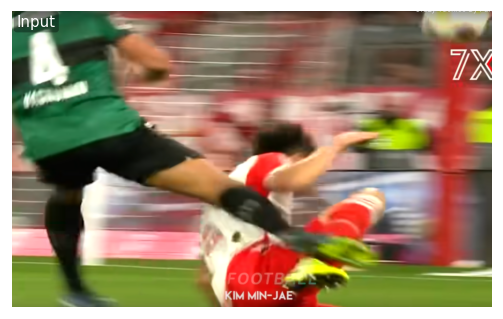

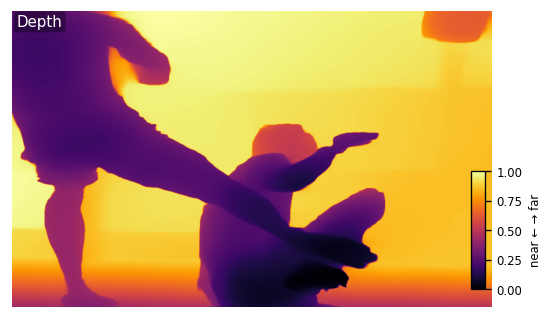

In [7]:
plot_depth(
    img_np,
    depth_map,
    fig_w=4,
    cmap="inferno",
    show_cb=True,
)

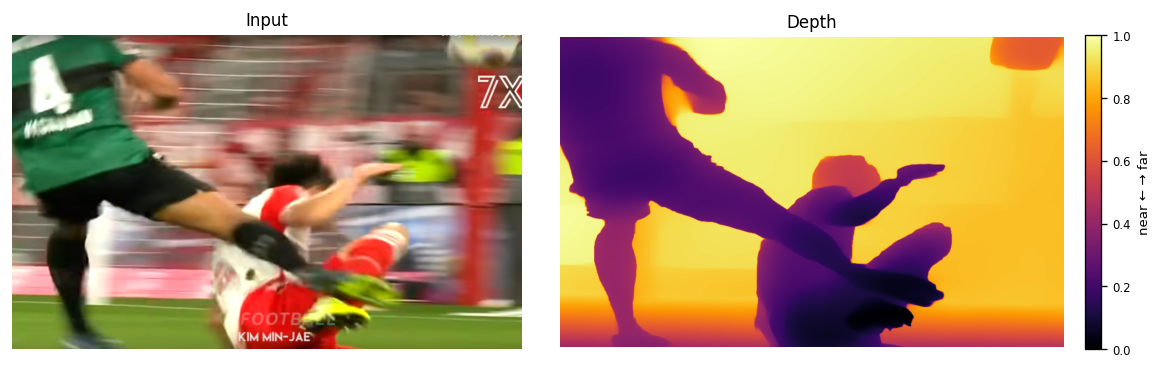

In [8]:
plot_comparison(img_np, depth_map, fig_w=10, cmap="inferno")

#### 3D 포인트 클라우드 (정성적, 상대 깊이)

아래는 원본 노트북과 동일하게 `max_depth=2.0` 스케일입니다. Open3D가 없으면 matplotlib 3D로 대체됩니다.

In [9]:
points, colors = depth_to_pointcloud(
    depth_map=depth_map,
    img_np=img_np,
    max_depth=2.0,
)
print("points:", points.shape, "colors:", None if colors is None else colors.shape)

show_pointcloud(points, colors, title="Depth Anything — point cloud")

points: (1487178, 3) colors: (1487178, 3)


In [10]:
points

array([[-0.24765097, -0.15251093,  0.49530196],
       [-0.2479717 , -0.15290523,  0.4965825 ],
       [-0.24876276, -0.15359095,  0.49880946],
       ...,
       [ 0.48389822,  0.29852894,  0.9715476 ],
       [ 0.48295206,  0.29756078,  0.9683968 ],
       [ 0.48267034,  0.29700398,  0.9665847 ]],
      shape=(1487178, 3), dtype=float32)